In [4]:
!unzip number.zip -d file


Streaming output truncated to the last 5000 lines.
  inflating: file/DevanagariHandwrittenDigitDataset/Train/digit_7/10299.png  
  inflating: file/DevanagariHandwrittenDigitDataset/Train/digit_7/10300.png  
  inflating: file/DevanagariHandwrittenDigitDataset/Train/digit_7/10301.png  
  inflating: file/DevanagariHandwrittenDigitDataset/Train/digit_7/10302.png  
  inflating: file/DevanagariHandwrittenDigitDataset/Train/digit_7/10303.png  
  inflating: file/DevanagariHandwrittenDigitDataset/Train/digit_7/10304.png  
  inflating: file/DevanagariHandwrittenDigitDataset/Train/digit_7/10306.png  
  inflating: file/DevanagariHandwrittenDigitDataset/Train/digit_7/10307.png  
  inflating: file/DevanagariHandwrittenDigitDataset/Train/digit_7/104017.png  
  inflating: file/DevanagariHandwrittenDigitDataset/Train/digit_7/104018.png  
  inflating: file/DevanagariHandwrittenDigitDataset/Train/digit_7/104019.png  
  inflating: file/DevanagariHandwrittenDigitDataset/Train/digit_7/104021.png  
  inflati

In [1]:
import tensorflow as tf
print(tf.keras.__version__)

3.8.0


## Task 1: Data Preparation

**Loading the Data**

• Download the provided folder that contains the Devnagari digits dataset.

• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.

• Use train folder for training and test for testing.
• Extract the corresponding labels for each image.

**Hints:**

• Ensure that the images are resized to a consistent shape (e.g., 28x28).

• Convert labels to one-hot encoded format for multi-class classification.

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


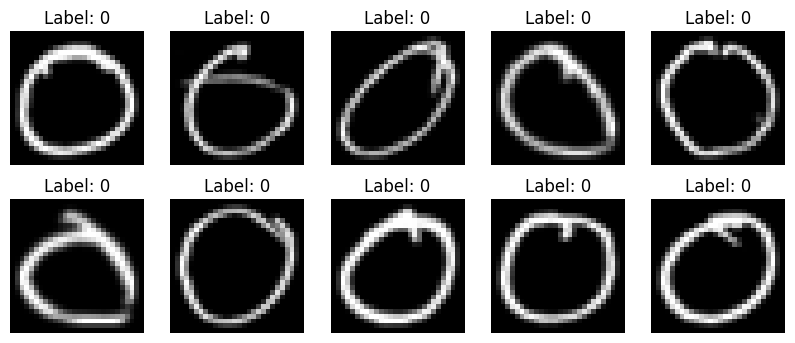

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image  # Import Pillow
# Define dataset paths
train_dir = "/content/file/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/file/DevanagariHandwrittenDigitDataset/Test"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))  # Sorted class names (digit_0, digit_1, ...)
    class_map = {name: i for i, name in enumerate(class_names)}  # Map class names to labels

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            # Load image using PIL
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            img = img.resize((img_width, img_height))  # Resize to (28,28)
            img = np.array(img) / 255.0  # Normalize pixel values to [0,1]
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1)  # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.show()

# Model parameters
num_classes = 10
input_shape = (28, 28, 1)

def build_functional_model():
    # Input layer
    inputs = keras.Input(shape=input_shape)
    # Flatten layer
    x = keras.layers.Flatten()(inputs)
    # Hidden layers
    x = keras.layers.Dense(64, activation="sigmoid")(x)
    x = keras.layers.Dense(128, activation="sigmoid")(x)
    x = keras.layers.Dense(256, activation="sigmoid")(x)
    # Output layer
    outputs = keras.layers.Dense(num_classes, activation="softmax")(x)
    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
model = build_functional_model()
model.summary()

In [7]:
model.compile(
  optimizer="sgd", # Stochastic Gradient Descent
  loss="categorical_crossentropy", # Loss function for multi-class classification
  metrics=["accuracy"] # Track accuracy during training
)

In [8]:
batch_size = 128
epochs = 1000

In [9]:
callbacks = [
  keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras")
]

In [10]:
history = model.fit(
  x_train,
  y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_split=0.15,
  callbacks=callbacks,
)

Epoch 1/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.1193 - loss: 2.2747 - val_accuracy: 0.0000e+00 - val_loss: 4.0775
Epoch 2/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1113 - loss: 2.1932 - val_accuracy: 0.0000e+00 - val_loss: 4.4920
Epoch 3/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1203 - loss: 2.1895 - val_accuracy: 0.0000e+00 - val_loss: 4.7682
Epoch 4/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1193 - loss: 2.1868 - val_accuracy: 0.0000e+00 - val_loss: 4.9310
Epoch 5/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1242 - loss: 2.1810 - val_accuracy: 0.0000e+00 - val_loss: 5.0241
Epoch 6/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1276 - loss: 2.1812 - val_accuracy: 0.0000e+00 - val_loss: 5.1607
Epoch 7/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1380 - loss: 2.1824 - val_accuracy: 0.0000e+00 - val_loss: 5.2900
Epoch 8/1000
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accur

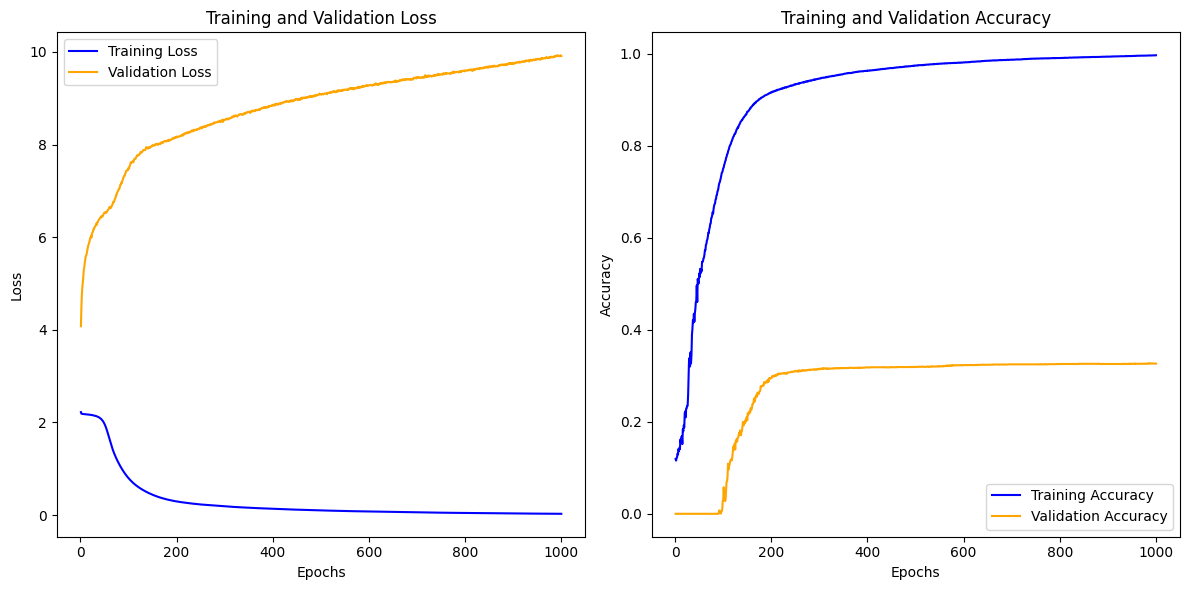

In [11]:
import matplotlib.pyplot as plt

# Assuming 'history' is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history.get('accuracy')
val_acc = history.history.get('val_accuracy')

# Plotting training and validation loss
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
if train_acc is not None and val_acc is not None:
    plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
    plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
else:
    plt.text(0.5, 0.5, 'Accuracy metrics not available', horizontalalignment='center', verticalalignment='center')
    plt.axis('off')

plt.tight_layout()
plt.show()
